In [11]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

# load general packages
import numpy as np
import matplotlib.pyplot as plt
import time

# load modules related to this exercise
from model_zurcher import zurcher
from solve_NFXP import solve_NFXP
import estimate_NFXP as estimate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


#### Before solving the exercise, you should download line_profiler. Line_profiler is a tool to check the performance of our code. To install line_profiler, you can open anaconda prompt and write "pip install line-profiler" (without the " " of course). If you want to know more about line_profiler, check the link below:

https://github.com/rkern/line_profiler.

# Exercise 1

#### Consider the engine replacement model given by:

$$
V(x,\epsilon) = \max_{d\in \{0,1\}} \big\{ u(x,d) + \epsilon(d) + \beta
\underbrace{\int_{X} \int_{\Omega} V(x',\epsilon') p(x'|x,d) q(\epsilon'|x') dx' d\epsilon' }_{EV(x,d)} \big\}
$$

Where $ \varepsilon $ is extreme value Type I distribued and utility is given by:

$$
u(x,d)=\left \{
\begin{array}{ll}
    -RC-c(0,\theta_1) & \text{if }d=\text{replace}=1 \\
    -c(x,\theta_1) & \text{if }d=\text{keep}=0
\end{array} \right.
$$

Here

- $ RC $ = replacement cost  
- $ c(x,\theta_1) $ = cost of maintenance with preference parameters $ \theta_1 $  

And in integrated value function form:
$$\bar{V}(x)=\int_{\Omega} \left[ \max_{d\in \{0,1 \}} \{ u(x,d)+\epsilon(d)+\beta \int_{X} \bar{V}(x')p(x'\vert x,d) dx'  \} \right] d\epsilon$$


### 1. Look at ReadMe.txt to get an overview of the code

### 2. Investigate how the code works: ensure you understand:
<il type ="a">
<li> zurcher.init</li>
<li> zurcher.setup</li>
<li> zurcher.create_grid</li>
<li> zucher.state_transition </li>
<li> zucher.bellman </li>

You can see how they are called below
    

### 3. Run the code below and make sure you understand what we are printing. 
What does the last transition probability in each (non-truncated) row (equal to 0.05 here) come from?

In [ ]:
do_settings = { 'RC': 0.5, 'n': 12, 'p':[0.65,0.2,0.1] }

model = zurcher(**do_settings)

print(f'Milage grid:\n{model.grid}\n')
print(f'Transition probabilities conditional on not replacing, d=0:\n{model.P1}\n')
print(f'Transition probabilities conditional on replacing, d=1:\n{model.P2}\n')

Vbar = model.bellman(np.zeros((model.n)),output=1)
print(f'Bellman one iteration of VFI:\n{Vbar}',)

Milage grid:
[ 0  1  2  3  4  5  6  7  8  9 10 11]

Transition probabilities conditional on not replacing, d=0:
[[0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.65 0.2  0.1  0.05 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.65 0.2  0.1  0.05 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.65 0.2  0.1  0.05 0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.65 0.2  0.1  0.05 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.65 0.2  0.1  0.05]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.65 0.2  0.15]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.65 0.35]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]]

Transition probabilities conditional on replacing, d=1:
[[0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.65 0.2 

#### Newton's Method

Next, we need to solve the model. Rust 1987 uses Newton–Kantorovich (NK) theorem to solve the Bellman equation in the engine replacement model. To understand the NK algorithm, consider using the Newton's method to solve the single-variable equation, $f(x)=0$. The Newton method uses the iterative procedure stated below to solve the equation:

$$x_{n+1} = x_{n} - \frac{f(x_n)}{f'(x_n)}$$

### 4. Use the Newton's Method to solve the equation below. Fill in the Newton step. Try to change the starting value and see if the solution changes.


$$f(x) = 3x^2 - \exp(x)=0$$

$$f'(x) = g(x) = 6x-\exp(x) $$

Root of f(x): 3.73
Number of iterations to achieve convergence: 6


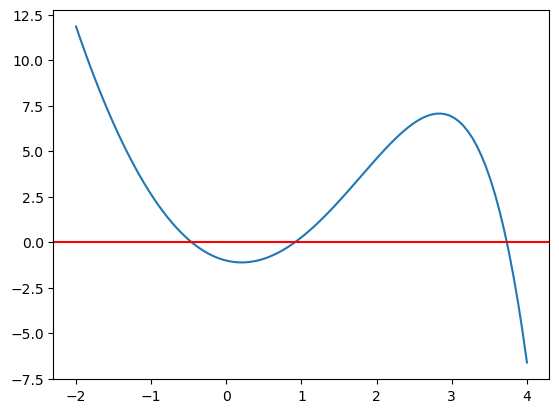

In [13]:
f = lambda x: 3*x**2-np.exp(x)
g = lambda x: 6*x-np.exp(x)

def newton(f, g, x0, tol=10e-5, max_iter=100):

    # initialize
    delta = 2000
    i = 0

    # iterate
    while (i<=max_iter and delta>tol):
        # FILL IN. Delete "None"
        x1 = None

        ### SOLUTION ###
        x1 = x0 - f(x0)/g(x0)
        ### SOLUTION ###

        delta = abs(x1-x0)

        i += 1
        x0 = x1

    return x1, i


x0,it = newton(f = f, g = g, x0 = 5)

x = np.linspace(-2, 4, num=100)
fx = f(x)
plt.plot(x, fx)
plt.axhline(y=0, color='r', linestyle='-')

print('Root of f(x):', round(x0,2))
print('Number of iterations to achieve convergence:', it)

#### Newton-Kantorovich

Now consider solving the engine replacement model. To do so, we need to find the integrated value function that solves the Bellman equation.

$$
\bar{V}(x) =  \bar{\Gamma}(\bar{V})(x) \quad\Leftrightarrow\quad (I - \bar{\Gamma})(\bar{V})(x)=\mathbb{0}
$$

Similar to the Newton iteration, the **NK iteration** uses the following equation

$$
\bar{V}_{k+1} = \bar{V}_{k} - (I-\bar{\Gamma}')^{-1} (I-\bar{\Gamma})(EV_k)
$$

- The new operator $(I - \bar{\Gamma})(\bar{V})$ is the difference between the identity operator $I$ and Bellman operator $ \Gamma  $  
- $ \mathbb{0} $ is "zero function" 
- $ I-\Gamma' $ is a Fréchet derivative of the operator $ I-\Gamma $  

### 5. Solve the model. In order to solve the model, you should understand:
<li> solve_NFXP.init</li>
<li> solve_NFXP.setup</li>
<li> solve_NFXP.poly </li>
<li> solve_NFXP.sa </li>
<li> solve_NFXP.nk </li>
</il>

You can see how they are called below: 

In [14]:
algorithm = 'poly'
do_settings_solver = {

    'sa_min': 10,
    'sa_max': 1000000,  
    'printfxp': 2
}

solver = solve_NFXP(**do_settings_solver)
model = zurcher()

In [15]:
Vbar0 = np.zeros((model.n)) # Initial guess
if algorithm == 'sa':
    Vbar = solver.sa(model.bellman, Vbar0)

elif algorithm == 'poly':
    Vbar = solver.poly(model.bellman, Vbar0, beta = model.beta)

else:
    print('Algorithm must be "sa" or "poly"')


Beginning SA-iterations (for the 1 time)

Iteration 1	tol: 0.4273	tol(j)/tol(j-1): nan
Iteration 2	tol: 0.4272	tol(j)/tol(j-1): nan
Iteration 3	tol: 0.4272	tol(j)/tol(j-1): nan
Iteration 4	tol: 0.4271	tol(j)/tol(j-1): nan
Iteration 5	tol: 0.4271	tol(j)/tol(j-1): nan
Iteration 6	tol: 0.4270	tol(j)/tol(j-1): nan
Iteration 7	tol: 0.4269	tol(j)/tol(j-1): nan
Iteration 8	tol: 0.4268	tol(j)/tol(j-1): nan
Iteration 9	tol: 0.4266	tol(j)/tol(j-1): nan
Iteration 10	tol: 0.4264	tol(j)/tol(j-1): nan
Iteration 11	tol: 0.4262	tol(j)/tol(j-1): 0.9994

SA stopped prematurely due to relative tolerance. Start NK iterations

Elapsed time 0.0081 seconds

Beginning NK-iterations (for the 1 time)

Iteration 1	tol: 13.1676	tol(j)/tol(j-1): 1.0000
Iteration 2	tol: 0.3080	tol(j)/tol(j-1): 0.0234
Iteration 3	tol: 0.0896	tol(j)/tol(j-1): 0.2907
Iteration 4	tol: 0.0033	tol(j)/tol(j-1): 0.0369
Iteration 5	tol: 0.0000	tol(j)/tol(j-1): 0.0035
Iteration 6	tol: 0.0000	tol(j)/tol(j-1): 0.0000

NK converged after 6 ite

#### 6. Now we have to estimate the model. In order to estimate the model, you should understand:
<il type ="a">
<li> zurcher.read_busdata </li>
<li> estimate_NFXP.estimate  </li>
<li> estimate_NFXP.ll  </li>
</il>

You can see how they are called below:

#### 7. Estimate the model

In [16]:
# Set up the model
model = zurcher()

# Set-up solver
solver = solve_NFXP()

# Read the data
data = model.read_busdata(bustypes=[1,2,3,4])
N = data.shape[0]

In [17]:
print(f'dataset contains {N} observations with {(data['d'] == 1).sum()} engine replacements')

data.head(10)

dataset contains 8156 observations with 60 engine replacements


,d,x,dx1
1,0.0,2,1
2,0.0,3,1
3,0.0,5,2
4,0.0,7,2
5,0.0,9,2
6,0.0,10,1
7,0.0,12,2
8,0.0,14,2
9,0.0,16,2
10,0.0,17,1


In [18]:
# estimate the model
t0 = time.time()
theta0 = [0,0]

# args for nfxp estimate
output_aux=estimate.estimate(model, solver, data, theta0 = theta0, twostep=True)
nfxp_model, optim_res, pnames, theta_hat, Avar, converged = output_aux

time_ = time.time()-t0

In [19]:
# Print the result
print(f'Structual estimation using busdata from Rust(1987)')
print(f'Beta        = {model.beta:.4f}')
print(f'n           = {model.n}')
print(f'Sample size = {N}\n \n')

print(f'Parameters     Estimates    s.e. ') 
print(f'{pnames[0]}             {theta_hat[0]:.4f}     {np.sqrt(Avar[0,0]):.4f} ')
print(f'{pnames[1]}              {theta_hat[1]:.4f}     {np.sqrt(Avar[1,1]):.4f} \n ')
print(f'{pnames[2]}(1)           {theta_hat[2]:.4f}     {np.sqrt(Avar[2,2]):.4f}  ')
print(f'{pnames[2]}(2)           {theta_hat[3]:.4f}     {np.sqrt(Avar[3,3]):.4f}  ')
print(f'{pnames[2]}(3)           {theta_hat[4]:.4f}     {np.sqrt(Avar[4,4]):.4f}  ')
print(f'{pnames[2]}(4)           {theta_hat[5]:.4f}     {np.sqrt(Avar[5,5]):.4f}  \n')

print(f'Log-likelihood {-optim_res.fun*N:.2f}') 
print(f'runtime (seconds) {time_:.4f}')
print(f'The model converged: {converged}')

Structual estimation using busdata from Rust(1987)
Beta        = 0.9999
n           = 175
Sample size = 8156
 

Parameters     Estimates    s.e. 
RC             9.7689     1.2264 
c              1.3427     0.3153 
 
p(1)           0.1069     0.0035  
p(2)           0.5154     0.0059  
p(3)           0.3621     0.0055  
p(4)           0.0143     0.0013  

Log-likelihood -8599.86
runtime (seconds) 2.3767
The model converged: True


#### 8. Try using line_profiler in python. This gives you a lot of information about the performance of your code

In [20]:
%lprun -f estimate.ll  -f estimate.estimate estimate.estimate(model, solver,data,theta0=theta0, twostep=0)

Timer unit: 1e-09 s

Total time: 1.54606 s
File: /Users/mikkelrich/dp_ucph/2_dynamic_discrete_choice/exercises/ex_ante/01_02_NFXP/estimate_NFXP.py
Function: estimate at line 12

Line #      Hits         Time  Per Hit   % Time  Line Contents
    12                                           def estimate(model, solver, data, theta0=[0,0], twostep=True):
    13                                           
    14         1      14000.0  14000.0      0.0      samplesize = data.shape[0]
    15                                           
    16                                               # 1. set ev has global variable
    17                                               global Vbar
    18         1       9000.0   9000.0      0.0      Vbar = np.zeros((model.n)) 
    19                                               
    20                                               # 2. find p non-parametrically by the relative frequencies of each milage change
    21         1    1879000.0    2e+06      0.1 

In [21]:
ev0 = np.zeros((model.n)) # Initial guess
%lprun -f solve_NFXP.nk -f solve_NFXP.poly solve_NFXP.poly(solver,model.bellman, ev0, beta = model.beta)

Timer unit: 1e-09 s

Total time: 0.03589 s
File: /Users/mikkelrich/dp_ucph/2_dynamic_discrete_choice/exercises/ex_ante/01_02_NFXP/solve_NFXP.py
Function: poly at line 36

Line #      Hits         Time  Per Hit   % Time  Line Contents
    36                                               def poly(self,bellman, V0=np.zeros(1), beta= 0.0, output=1):
    37                                                   """
    38                                                   Solves the model using the poly-algorithm.
    39                                                   set beta = 0.0 if you want to solve only with successive approximations.
    40                                                   """
    41                                           
    42                                                   # 1. set starting time
    43         1       2000.0   2000.0      0.0          t0poly = time.time()
    44                                           
    45                                    

#### 9. In the code, we are using analytical hessian and gradient. Let us now try to use numerical equivalents. 


a) Now try changing the optimizer options, and turn the use of the non-numerical Hessian off . What happens?

b) Now also try it with the analytical gradient off, what happens?

Note that the file $\texttt{estimate\_NFXP\_altspec1.py}$ contains an equivalent implementation of the estimation procedure in $\texttt{estimate\_NFXP.py}$. However, when the NFXP algorithm runs without the analytical gradients and hessians, then the implementation in $\texttt{estimate\_NFXP\_altspec1.py}$ is superior (altough less readable). Therefore, we import this implementation here for a fair comparison.

In [22]:
# Turn off warnings: We turn of warnings as a result of overflow.
# This occurs as the optimizer will sometimes guess on non-feasible transition probabilities.
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [23]:
import estimate_NFXP_altspec1
model = zurcher()
solver = solve_NFXP()

# 1. ordinary
print('BHHH:')
%timeit nfxp_results = estimate_NFXP_altspec1.estimate(model, solver, data,theta0=theta0, twostep=0, est_type=0)

# 2. hessian off
print('')
print('Hessian is off:')
%timeit nfxp_result = estimate_NFXP_altspec1.estimate(model, solver, data, twostep=0, est_type=1)

# 3. hessian and gradient ofF 
print('')
print('Hessian and gradient are off:')
%timeit nfxp_results = estimate_NFXP_altspec1.estimate(model, solver, data,theta0=theta0, twostep=0, est_type=2)

BHHH:
Time is 2.3498 seconds. The model converges: True
Time is 2.5649 seconds. The model converges: True
Time is 1.9416 seconds. The model converges: True
Time is 1.8402 seconds. The model converges: True
Time is 1.8473 seconds. The model converges: True
Time is 2.5962 seconds. The model converges: True
Time is 2.0694 seconds. The model converges: True
Time is 2.0530 seconds. The model converges: True
2.13 s ± 296 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Hessian is off:
Time is 3.7504 seconds. The model converges: True
Time is 4.2497 seconds. The model converges: True
Time is 4.9225 seconds. The model converges: True
Time is 4.0541 seconds. The model converges: True
Time is 4.8883 seconds. The model converges: True
Time is 4.9379 seconds. The model converges: True
Time is 3.9252 seconds. The model converges: True
Time is 4.0775 seconds. The model converges: True
4.44 s ± 425 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Hessian and gradient are off:
Time is 4.95

#### 9. Try estimate the model for different values of $\beta$. 

(a) Why can we not estimate $\beta$?

(b) When estimating with different $\beta$, do the changes in the estimates of c and/or RC make intuitively sense?

(c) Can you think of some data/variation, which could allow us to identify $\beta$?

In [24]:
# 1. make beta grid
Nbeta = 4
beta = np.linspace(0.5, 0.9999, Nbeta)

# 2. allocate
log_lik = np.zeros(Nbeta) + np.nan
theta_hats = np.zeros((Nbeta,2)) + np.nan

# 3. read data
data = model.read_busdata(bustypes=[1,2,3,4])
samplesize = data.shape[0]

# 4. print
print(f'beta     RC     C       log_lik')

# 5. loop over beta grid
for i in range(Nbeta):
    
    # a. set up the model
    do_settings = {'beta': beta[i]}
    model = zurcher(**do_settings)

    # b. set up solver
    solver = solve_NFXP()

    # c. estimate the model
    theta0 = [0,0]
    output_aux = estimate.estimate(model, solver, data, theta0 = theta0, twostep = 0)
    nfxp_model, optim_res, pnames, theta_hat, Avar, converged = output_aux
    
    # d. store and print
    theta_hats[i,0] = theta_hat[0]
    theta_hats[i,1] = theta_hat[1]
    log_lik[i]=-optim_res.fun*samplesize
    print(f'{beta[i]:.4f} {theta_hats[i,0]:.4f} {theta_hats[i,1]:.4f} {log_lik[i]} ')

beta     RC     C       log_lik
0.5000 7.3664 18.5137 -306.6265260686432 
0.6666 7.4239 12.6984 -306.3332199654304 
0.8333 7.6018 6.9196 -305.4929182757053 
0.9999 9.7689 1.3427 -300.56984941694657 


#### 10. We use the latest EV guess to start the solve-procedure even though we change $\theta$ from one likelihood iteration to another. Why do you think we do that? 

(a) What if we started over with EV=0 each iteration? Try that and see what happens with the parameters and the numerical performance.

As in (9), we here use $\texttt{estimate\_NFXP\_altspec2.py}$

In [25]:
import estimate_NFXP_altspec2

print('Recycle latest Vbar as guess')
%timeit estimate_NFXP_altspec2.estimate(model, solver,data,0)
nfxp_results_ord, theta_hat_ord = estimate_NFXP_altspec2.estimate(model, solver, data,0)

print('Trivial Vbar guess')
%timeit estimate_NFXP_altspec2.estimate(model, solver,data,1)
nfxp_results_diff, theta_hat_diff = estimate_NFXP_altspec2.estimate(model, solver, data,1)

print('')
print(f'                 Same EV       EV=0')
print(f'{pnames[0]}               {theta_hat_ord[0]:.4f}       {theta_hat_diff[0]:.4f}')
print(f'{pnames[1]}                {theta_hat_ord[1]:.4f}       {theta_hat_diff[1]:.4f}')

Recycle latest Vbar as guess
2.81 s ± 528 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Trivial Vbar guess
4.01 s ± 703 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

                 Same EV       EV=0
RC               9.7689       9.7689
c                1.3427       1.3427


#### 11. Try setting the maximum number of miles (odometer reading) to 720 (multiplied previous maximum by 1.6). Now the absorbing state is much higher. 

(a) If we adjust the number of grid points as well, so that we have a comparable model (multiply the number of grids by 1.6), do we get a better fit? 

(b) Try to lower the number of grid points to 175 again. How do the parameters change? Are the changes intuitive? 

(c) Optional: What if you change the max to 225 and half the number of grids (hint: what goes wrong?)?

In [26]:
def adjust_grid_point(maks, n): # function for adjusting grid-points

    # 1. set up the model
    do_settings = {'max' : maks, 'n' : n}
    model = zurcher(**do_settings)

    # 2. set up solver
    solver = solve_NFXP()
        
    # 3. read the data
    data = model.read_busdata(bustypes=[1,2,3,4])
    samplesize = data.shape[0]

    # 4. estimate the model
    theta0 = [0,0]
    nfxp_model, result, pnames, theta, Avar, converged=estimate.estimate(model, solver,data,theta0=theta0, twostep=0)
    
    print(f'Parameters     Estimates    s.e. ') 
    print(f'{pnames[0]}             {theta[0]:.4f}     {np.sqrt(Avar[0,0]):.4f} ')
    print(f'{pnames[1]}              {theta[1]:.4f}     {np.sqrt(Avar[1,1]):.4f} \n ')
    print(f'Log-likelihood now {-result.fun*samplesize:.4f}\n \n') 

In [27]:
# Baseline max = 450, n = 175
print(f'Baseline')
adjust_grid_point(450,175)

# a)  max = 720, n = 280
print(f'Question (a)')
adjust_grid_point(int(450*1.6),int(175*1.6))

# b) max = 720., n = 175
print(f'Question (b)')
adjust_grid_point(int(450*1.6),175)

# c) max =225, n = 175/2
print(f'Question (c)')
adjust_grid_point(int(450/2),int(200/2));

Baseline
Parameters     Estimates    s.e. 
RC             9.7689     1.2260 
c              1.3427     0.3152 
 
Log-likelihood now -300.5698
 

Question (a)
Parameters     Estimates    s.e. 
RC             9.7656     1.2377 
c              1.3402     0.3202 
 
Log-likelihood now -300.5877
 

Question (b)
Parameters     Estimates    s.e. 
RC             9.7454     1.2323 
c              2.1482     0.5126 
 
Log-likelihood now -300.4841
 

Question (c)


IndexError: index 100 is out of bounds for axis 0 with size 100